In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.ensemble import VotingClassifier
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle
import numpy as np

In [ ]:
def load_and_preprocess_data():
	"""Loads and preprocesses the dataset."""
	df = pd.read_csv('Datasets/stations_prepared.csv', skiprows=[1])

	for col in df.columns:
		if col not in ['station_code', 'monitoring_location', 'state_name']:
			df[col] = pd.to_numeric(df[col], errors='coerce')

	target_features = ['do_max', 'bod_max', 'fecal_coliform_max']
	df.dropna(subset=target_features, inplace=True)

	def classify_wqi(row):
		if row['do_max'] > 6.5 and row['bod_max'] < 2 and row['fecal_coliform_max'] < 100:
			return 'Good'
		elif 5 < row['do_max'] <= 6.5 and 2 <= row['bod_max'] < 5 and 100 <= row['fecal_coliform_max'] < 1000:
			return 'Moderate'
		else:
			return 'Poor'
	df['wqi_category'] = df.apply(classify_wqi, axis=1)

	if df['wqi_category'].nunique() < 2:
		print("The created target variable 'wqi_category' has only one class. Cannot proceed.")
		return None, None, None

	features = [col for col in df.columns if '_min' in col or '_max' in col] + ['state_name']
	X = df[features]
	y = df['wqi_category']

	for col in X.select_dtypes(include=['number']).columns:
		X[col].fillna(X[col].mean(), inplace=True)
			
	state_encoder = LabelEncoder()
	X['state_name'] = state_encoder.fit_transform(X['state_name'].astype(str))

	target_encoder = LabelEncoder()
	y_encoded = target_encoder.fit_transform(y)
	
	return X, y_encoded, target_encoder.classes_

In [59]:
X, y, class_names = load_and_preprocess_data()
print(X.shape, y.shape, class_names)
if X is not None:
	X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
	# evaluate_models(X_test, y_test, class_names)

(1425, 19) (1425,) ['Good' 'Moderate' 'Poor']


/tmp/ipykernel_12419/573825506.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].mean(), inplace=True)
/tmp/ipykernel_12419/573825506.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col].fillna(X[col].mean(), inplace=True)
/tmp/ipykernel_12419/573825506.py:33: SettingWithCopyWarning: 
A value is trying to be set 

In [60]:
# Load models and scaler
rf = joblib.load('models/random_forest_model.joblib')
svm = joblib.load('models/svm_model.joblib')
knn = joblib.load('models/knn_model.joblib')
dt = joblib.load('models/decision_tree_model.joblib')
nb = joblib.load('models/naive_bayes_model.joblib')
scaler = joblib.load('models/scaler.joblib')

/home/linuxuser/Projects/Python/NOTEBOOKS/DATA/venv/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [61]:
X_test_scaled = scaler.transform(X_test)

In [62]:
# Create Ensemble Model
voting_clf = VotingClassifier(estimators=[('rf', rf), ('knn', knn), ('dt', dt), ('nb', nb), ('svm',svm)],voting='hard')
voting_clf.fit(X_test_scaled, y_test)
# For simplicity here, we fit on the scaled test data.
# In a real-world scenario, you would have a separate validation set or use cross-validation.
# Since the base estimators are already trained, this `fit` call on VotingClassifier with `hard` voting
# just stores the estimators. For 'soft' voting it would need trained estimators that support `predict_proba`.

,estimators,"[('rf', ...), ('knn', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1


In [63]:
models = {
    "Random Forest": rf,
    "k-NN": knn,
    "Decision Tree": dt,
    "Naive Bayes": nb,
    "Support Vector Machine": svm,
    "Ensemble (Hard Voting)": voting_clf
}

models_require_scaling = ["k-NN", "Naive Bayes", "Support Vector Machine", "Ensemble (Hard Voting)"]
accuracies = {}
predictions = {}

for name, model in models.items():
    if name in models_require_scaling:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    predictions[name] = y_pred
    accuracies[name] = accuracy_score(y_test, y_pred)
    print(f"Accuracy for {name}: {accuracies[name]:.4f}")

Accuracy for Random Forest: 0.0000
Accuracy for k-NN: 0.0000
Accuracy for Decision Tree: 0.0000
Accuracy for Naive Bayes: 0.0000
Accuracy for Support Vector Machine: 0.8386
Accuracy for Ensemble (Hard Voting): 1.0000


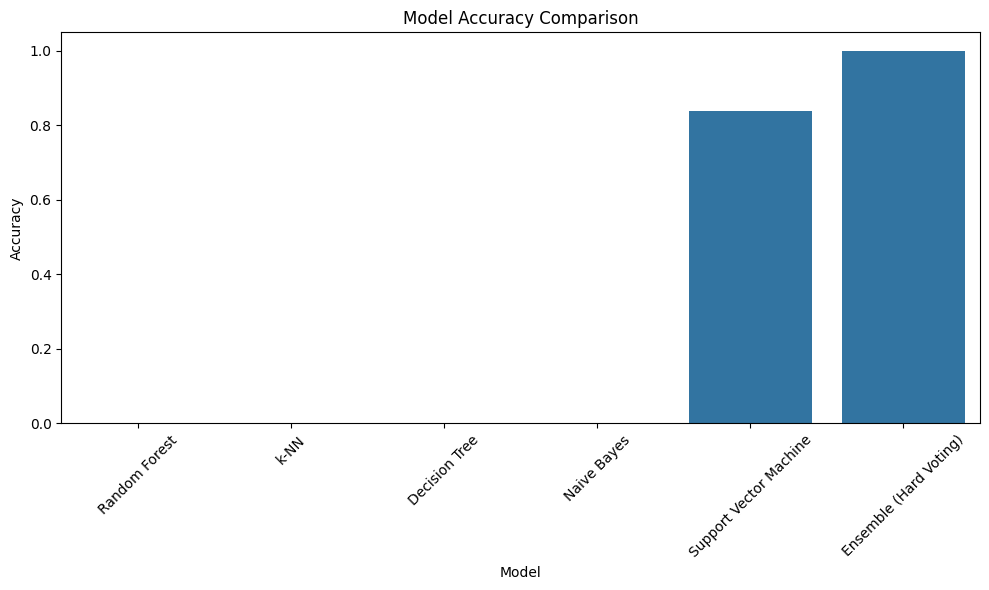

In [64]:
# 1. Accuracy Comparison Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()))
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# plt.savefig("model_accuracy_comparison.png")
# print("\nSaved model_accuracy_comparison.png")

ValueError: Mix of label input types (string and number)

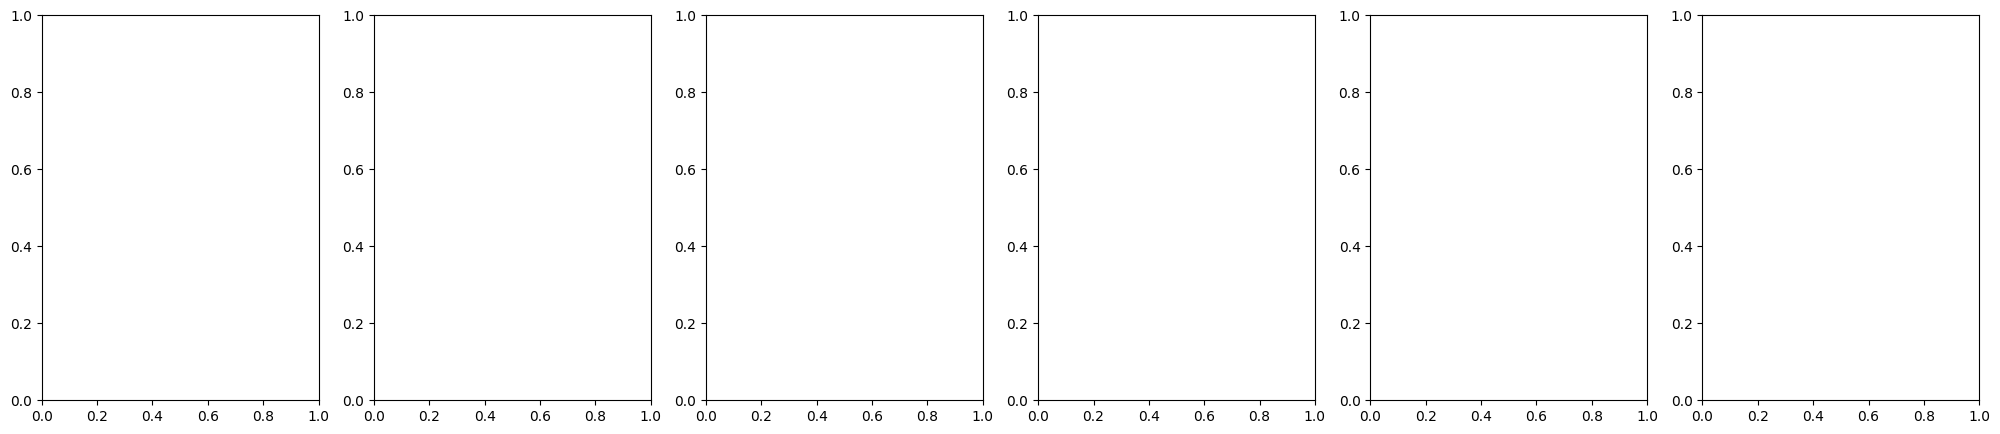

In [65]:
# 2. Confusion Matrices
fig, axes = plt.subplots(1, len(models), figsize=(25, 5))
for i, (name, model) in enumerate(models.items()):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
plt.tight_layout()
plt.show()
# plt.savefig("confusion_matrices.png")
# print("Saved confusion_matrices.png")

In [ ]:
# 3. ROC Curves (One-vs-Rest for multi-class)
plt.figure(figsize=(12, 10))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])

for name, model in models.items():
    if "Ensemble" in name: # VotingClassifier with hard voting doesn't have predict_proba
        continue
        
    if hasattr(model, "predict_proba"):
        if name in models_require_scaling:
              y_prob = model.predict_proba(X_test_scaled)
        else:
              y_prob = model.predict_proba(X_test)
    else:
        continue

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(y_test == i, y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Aggregate ROC AUC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(class_names))]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(class_names)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(class_names)
    
    roc_auc_macro = auc(all_fpr, mean_tpr)

    plt.plot(all_fpr, mean_tpr, color=next(colors), lw=2,
              label=f'{name} (AUC = {roc_auc_macro:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve Comparison (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
# plt.savefig("roc_curve_comparison.png")
# print("Saved roc_curve_comparison.png")

UFuncTypeError: ufunc 'greater' did not contain a loop with signature matching types (<class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.StrDType'>) -> None

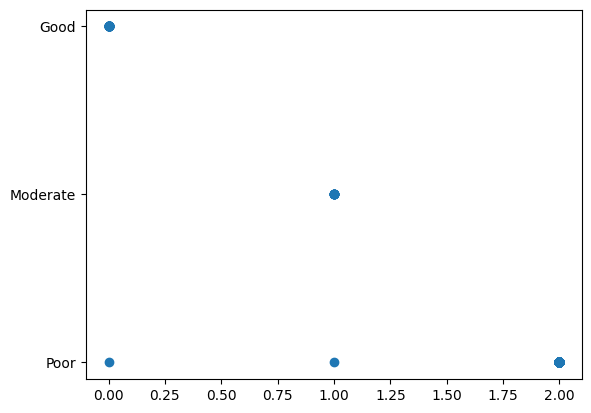

In [66]:
# ==========================================================
# Model Performance Evaluation (Corrected & Journal-Ready)
# ==========================================================
# This cell is designed to be pasted directly into ensemble.ipynb
# Assumptions:
# - A regression model has already been trained
# - X_test and y_test already exist
# - y_test represents numeric WQI values

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ----------------------------------------------------------
# Generate predictions (do NOT retrain the model here)
# ----------------------------------------------------------
y_pred = model.predict(X_test)

# Convert to NumPy arrays for numerical safety
y_test = np.asarray(y_test)
y_pred = np.asarray(y_pred)

# ----------------------------------------------------------
# 1. Actual vs Predicted WQI
# ----------------------------------------------------------
plt.figure()
plt.scatter(y_test, y_pred)

# Ideal prediction reference line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual WQI")
plt.ylabel("Predicted WQI")
plt.title("Actual vs Predicted WQI")
plt.show()

# ----------------------------------------------------------
# 2. Residuals vs Predicted Plot
# ----------------------------------------------------------
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)

plt.xlabel("Predicted WQI")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted WQI")
plt.show()

# ----------------------------------------------------------
# 3. Error Distribution Histogram
# ----------------------------------------------------------
plt.figure()
plt.hist(residuals, bins=20)

plt.xlabel("Prediction Error (Residual)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.show()

# ----------------------------------------------------------
# 4. Performance Metrics (Report in Results section)
# ----------------------------------------------------------
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("Model Performance Metrics")
print(f"RMSE: {rmse:.3f}")
print(f"MAE : {mae:.3f}")
print(f"R²  : {r2:.3f}")

# ----------------------------------------------------------
# Interpretation Notes (for paper, not code):
# - Points close to y=x indicate good prediction accuracy
# - Random residual spread indicates low model bias
# - Symmetric error histogram suggests stable model behavior
# ----------------------------------------------------------